In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [6]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\smart_city_demand_processed (1).csv")

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(0)

cat_cols = df.select_dtypes(include=['object', 'string']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1947 entries, 0 to 1946
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   holiday                     1947 non-null   str    
 1   temp                        1947 non-null   float64
 2   rain_1h                     1947 non-null   float64
 3   snow_1h                     1947 non-null   float64
 4   clouds_all                  1947 non-null   int64  
 5   weather_main                1947 non-null   str    
 6   weather_description         1947 non-null   str    
 7   date_time                   1947 non-null   str    
 8   traffic_volume              1947 non-null   float64
 9   hour                        1947 non-null   int64  
 10  day_of_week                 1947 non-null   int64  
 11  is_weekend                  1947 non-null   bool   
 12  is_rush_hour                1947 non-null   bool   
 13  transport_demand_level      1947 non-null   

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,temp_celsius,is_holiday
count,1947.000000,1947.0,1947.0,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000,1947.000000
mean,277.535064,0.0,0.0,64.308166,3301.587057,11.289676,2.961479,4.385064,0.001541
std,6.752843,0.0,0.0,35.037955,2033.100319,6.809348,2.002582,6.752843,0.039233
min,255.940000,0.0,0.0,0.000000,216.000000,0.000000,0.000000,-17.210000,0.000000
25%,272.685000,0.0,0.0,40.000000,1215.000000,5.000000,1.000000,-0.465000,0.000000
50%,277.990000,0.0,0.0,90.000000,3453.000000,11.000000,3.000000,4.840000,0.000000
75%,282.090000,0.0,0.0,90.000000,5102.500000,17.000000,5.000000,8.940000,0.000000
max,298.170000,0.0,0.0,100.000000,7189.000000,23.000000,6.000000,25.020000,1.000000


In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day_name()
df['month'] = df['date_time'].dt.month

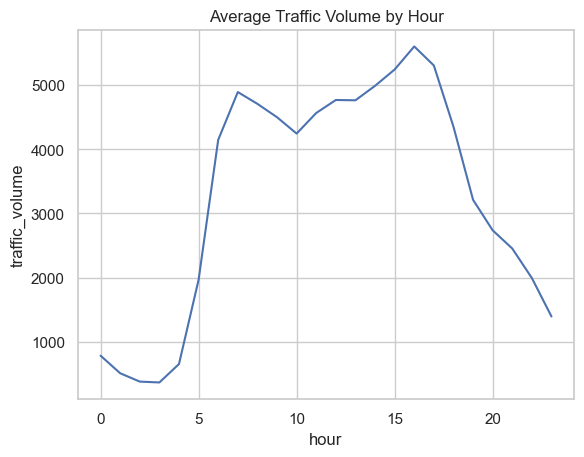

In [8]:
hourly_traffic = df.groupby('hour')['traffic_volume'].mean().reset_index()

sns.lineplot(data=hourly_traffic, x='hour', y='traffic_volume')
plt.title("Average Traffic Volume by Hour")
plt.show()

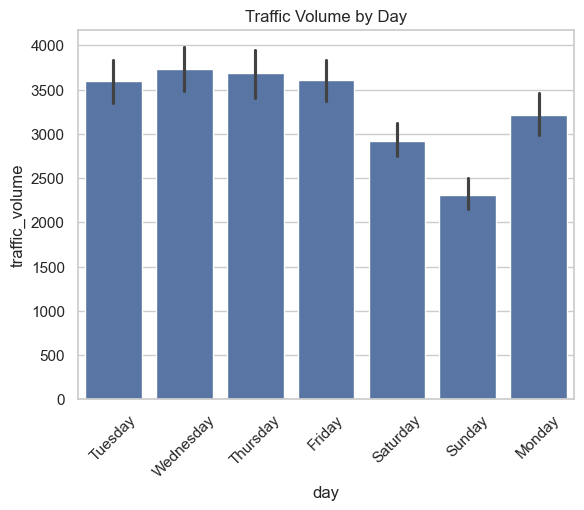

In [9]:
sns.barplot(data=df, x='day', y='traffic_volume')
plt.xticks(rotation=45)
plt.title("Traffic Volume by Day")
plt.show()

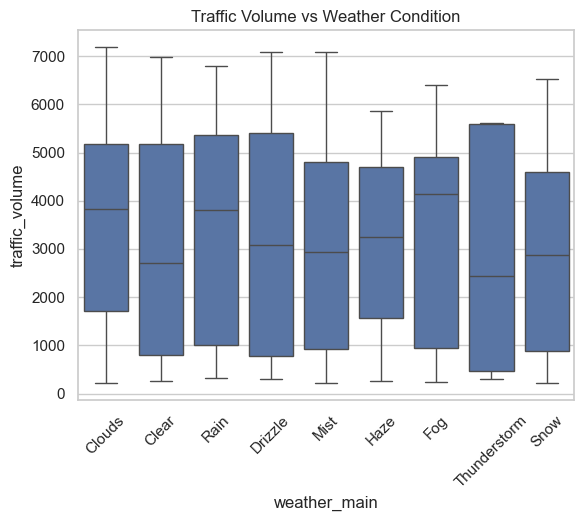

In [10]:
sns.boxplot(data=df, x='weather_main', y='traffic_volume')
plt.xticks(rotation=45)
plt.title("Traffic Volume vs Weather Condition")
plt.show()

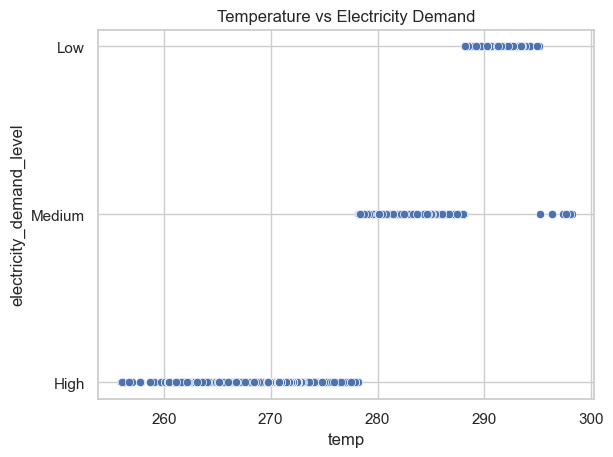

In [11]:
sns.scatterplot(data=df, x='temp', y='electricity_demand_level')
plt.title("Temperature vs Electricity Demand")
plt.show()

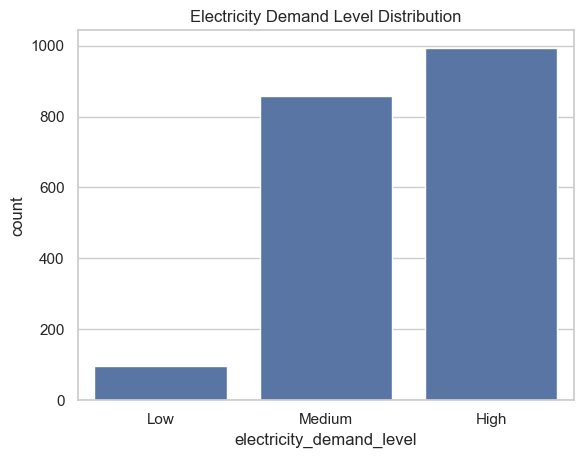

In [12]:
sns.countplot(data=df, x='electricity_demand_level')
plt.title("Electricity Demand Level Distribution")
plt.show()

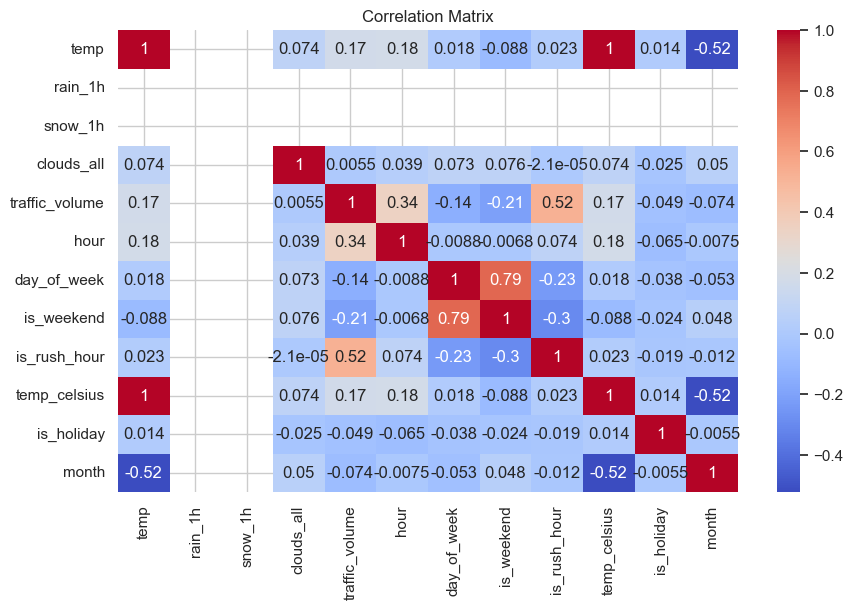

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [15]:
import sqlite3

conn = sqlite3.connect("smart_city.db")

df.to_sql("demand_data", conn, if_exists='replace', index=False)

query = "SELECT hour, AVG(traffic_volume) as avg_traffic FROM demand_data GROUP BY hour"
result = pd.read_sql(query, conn)

result.head()

,hour,avg_traffic
0,0,780.467532
1,1,505.937500
2,2,375.525641
3,3,362.440476
4,4,649.898876
